# Final | Research Investigation Notebook

In this notebook, you will do a research investigation of your chosen dataset in teams. You will begin by formally selecting your research question (task 0), then processing your data (task 1), creating a predictive model (task 2), evaluating your model's results (task 3), and describing the contributions of each team member (task 4).

For grading, please make sure your notebook has all cells run and is stored in your team's [Github Classroom repository](https://classroom.github.com/a/CNxME27U). You will also need to write a short, 2 page report about your design decisions as a team, to be stored in your repository. The Milestone 4 submission will be the contents of your repository at the due date (April 28 at 23:59 CET).

## Brief overview of Calcularis
[Calcularis](https://school.alemira.com/de/calcularis/) by Alemira School is a mathematics learning program developed with neuroscientists and computer scientists from ETH Zurich. It promotes the development and interaction of the different areas of the brain that are responsible for processing numbers and quantities and solving mathematical tasks. Calcularis can be used from 1st grade to high school. Children with dyscalculia also benefit in the long term and overcome their arithmetic weakness.

The Calcularis dataset has three main tables:
* ***users***: meta information about users (i.e. total time spent learning with Calcularis, geographic location).
* ***events***: events done by the users in the platform (i.e. playing a game, selecting a new animal in the zoo simulation).
* ***subtasks***: sub-tasks with answer attempts solved by users, primarily in the context of game events.

These tables and useful metadata information are described in detail in the [Milestone 2 data exploration notebook](https://github.com/epfl-ml4ed/mlbd-2023/blob/main/project/milestone-02/m2_calcularis_sciper.ipynb).

We have provided access to the [full dataset](https://moodle.epfl.ch/mod/forum/discuss.php?d=88179) (~65k users) and a randomly selected subset (~1k users from M2). We have also provided access to a [test account to experiment with Calcularis](https://moodle.epfl.ch/mod/forum/discuss.php?d=88094). You should provide arguments and justifications for all of your design decisions throughout this investigation. You can use your M3 responses as the basis for this discussion.

In [1]:
import seaborn as sns 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import pprint
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression 
from sklearn.neighbors import NearestNeighbors
from scipy import stats
from pyBKT.models import Model
from sklearn import model_selection
from scipy.stats import ttest_ind


from pprint import PrettyPrinter
pp = PrettyPrinter(indent=4, compact=True)
np.set_printoptions(precision=3, suppress=True)


%matplotlib inline

In [ ]:
# Import the tables of the data set as dataframes.
DATA_DIR = './data' # You many change the directory

events = pd.read_csv(DATA_DIR+'/full_calcularis_events.csv'.format(DATA_DIR), index_col=0)
subtasks = pd.read_csv(DATA_DIR+'/full_calcularis_subtasks.csv'.format(DATA_DIR), index_col=0)
users = pd.read_csv(DATA_DIR+'/full_calcularis_users.csv'.format(DATA_DIR), index_col=0)

In [4]:
print(len(events))
print(len(subtasks))
print(len(users))

2185200
3502884
64932


## Task 0: Research Question

***Research questions:***  
**A- Do students who use free training versus those who don't perform worse or better?**    
**B- How can we predict user performance on a set of skills, including addition, multiplication, number line, etc.?**

## Task 1: Data Preprocessing



**Events processing**

In [5]:
events.isna().any()

user_id             False
mode                 True
game_name            True
learning_time_ms     True
subtasks             True
number_range         True
start               False
end                  True
skill_id             True
type                False
dtype: bool

In [6]:
#events are indexed on users and events id
events = events.reset_index().set_index(['event_id', 'user_id'])
#remove nan values
events = events.dropna()
len(events)

2153208

In [7]:
#we end up solely with games data
events.type.unique()

array(['task'], dtype=object)

In [8]:
import ast 
#process subtasks syntax
events.subtasks = events.subtasks.map(lambda x : ast.literal_eval(x))

In [9]:
#example of subtask entry
events.subtasks.iloc[0]

[{'hasProperResult': True,
  'range': 'R10',
  'correct': False,
  'answer': 4,
  'correctNumber': 1,
  'type': 'ConciseSubitizingTaskDescription',
  'subtask_finished_timestamp': '2020-08-20T07:14:29.954Z',
  'correctAnswerObject': 1},
 {'mode': 'STEPS',
  'correct': True,
  'range': 'R10',
  'timeoutInSteps': 2,
  'timeoutInSeconds': 0.0,
  'answer': 2,
  'type': 'ConciseTimeoutDescription',
  'correctAnswerObject': None,
  'subtask_finished_timestamp': '2020-08-20T07:14:29.954Z',
  'hasProperResult': True}]

The second subtask entry in the example has no correctAnswerObject, hence one can't assess how far the student was from the answer. We decide that a subtask is valid if hasProperResult is True (subtask is answerable) and all of correct, type, answer and correctAnswerObject fields are present and valid. Also we want to consider the range field to be able to assess the level of the asnwered subtask.

In [10]:
def check_subtask_entry(x,fields={'correct', 'correctAnswerObject', 'answer', 'range', 'type'}):
    #we want to assess user's performance, theses fields are necessary to do so
    return len(fields.intersection(x))==len(fields) and x['hasProperResult'] and all([not x[f] is None for f in fields])

In [11]:
events_pre = events.copy()
events_pre.subtasks.map(lambda x :sum([ 1 if check_subtask_entry(xi) else 0 for xi in x])).value_counts().sort_index()
#events can have multiple subtasks, we need to filter out non valid subtasks entries

0        28441
1      1977111
2        38416
3        35337
4         7168
        ...   
104          2
108          1
124          2
127          1
147          1
Name: subtasks, Length: 89, dtype: int64

In [12]:
events_pre.subtasks = events_pre.subtasks.map(lambda x : [xi for xi in x if check_subtask_entry(xi)])
#drop events that end up with 0 valid subtasks entries
events_pre = events_pre.drop(events_pre[events_pre['subtasks'].map(len)==0].index)
#check on previous example
events_pre.subtasks.iloc[0]
print('length of events df : {}'.format(len(events_pre)))

length of events df : 2124767


Now we compute the score for each user in each event

In [13]:
#Assign a weight to each game based on its difficulty level
complexity_dict = {'R10': 1, 'R20': 2, 'R100': 10, 'R1000': 100}
#add the scores earned depending complexity for each event
score=events_pre.subtasks.map(lambda x : [complexity_dict[xi['range']] if xi['correct'] else 0 for xi in x])
#add the types of subtask for each event
subtypes = events_pre.subtasks.map(lambda x : [xi['type'] for xi in x])
events_pre['score'] = score
events_pre['sub_types'] = subtypes
events_pre

,,mode,game_name,learning_time_ms,subtasks,number_range,start,end,skill_id,type,score,sub_types
event_id,user_id,,,,,,,,,,,
1,2,NORMAL,Subitizing,"13,094.00000","[{'hasProperResult': True, 'range': 'R10', 'co...",R10,2020-08-20T07:13:50.876Z,2020-08-20T07:14:30.108Z,1.00000,task,[0],[ConciseSubitizingTaskDescription]
3,2,NORMAL,Conversion,"15,879.00000","[{'answer': 6, 'range': 'R10', 'correct': True...",R10,2020-08-21T07:02:20.112Z,2020-08-21T07:02:36.221Z,3.00000,task,[1],[ConciseConversionTaskDescription]
4,2,NORMAL,Landing,"6,075.00000","[{'range': 'R10', 'correct': True, 'lowerBound...",R10,2020-08-24T07:02:59.855Z,2020-08-24T07:03:07.382Z,18.00000,task,[1],[ConciseLandingTaskDescription]
5,2,NORMAL,Landing,"6,910.00000","[{'range': 'R10', 'correct': True, 'lowerBound...",R10,2020-08-26T06:47:21.504Z,2020-08-26T06:47:30.050Z,19.00000,task,[1],[ConciseLandingTaskDescription]
6,2,NORMAL,Calculator,"7,507.00000","[{'range': 'R20', 'answerMode': 'RESULT', 'cor...",R20,2020-08-26T07:20:58.766Z,2020-08-26T07:21:06.439Z,54.00000,task,[2],[ConciseEquationTaskDescription]
...,...,...,...,...,...,...,...,...,...,...,...,...
2399317,64997,END_OF_NR,Landing,"6,075.00000","[{'aim': 83, 'startPosition': 0.5, 'lowerBound...",R1000,2020-03-24T09:12:33.561Z,2020-03-24T09:12:43.293Z,179.00000,task,[100],[ConciseLandingTaskDescription]
2399318,64997,END_OF_NR,Estimation,"2,621.00000","[{'numbers': [974, 532, 160], 'type': 'Concise...",R1000,2020-03-26T07:43:29.873Z,2020-03-26T07:43:33.289Z,167.00000,task,[100],[ConciseEstimationTaskDescription]
2399319,64997,END_OF_NR,Secret Number,"68,768.00000",[{'type': 'ConciseNumberInIntervalTaskDescript...,R1000,2020-03-28T08:33:44.445Z,2020-03-28T08:34:53.298Z,178.00000,task,"[100, 100, 100, 100, 100, 100]","[ConciseNumberInIntervalTaskDescription, Conci..."


To be able to grasp the skill the user is working in a given event, we want to map the skill id field to the domain it corresponds to

In [14]:
#Read and pretty print content of pickle file skill_sets_ids.pkl
with open('data/skill_sets_ids_merged.pkl', 'rb') as f:
    skill_sets_ids = pickle.load(f)

pprint.pprint(skill_sets_ids, compact=True)

{'Addition': [186, 184, 191, 21, 125, 213, 57, 63, 130, 216, 58, 212, 121, 205,
              123, 218, 26, 193, 119, 132, 185, 192, 204, 22, 194, 54, 201, 215,
              217, 195, 202, 23, 183, 59, 214, 116, 219, 53, 114, 203],
 'Division': [162, 242, 249, 156, 87, 85, 241, 88, 245, 158, 247, 157, 155, 90,
              246, 243, 248, 91, 83, 160, 240, 251, 163, 159, 244, 86, 84, 161,
              82, 89],
 'Multiplication': [148, 141, 149, 236, 140, 78, 76, 238, 73, 77, 144, 237, 153,
                    150, 75, 139, 143, 142, 152, 80, 235, 74, 154, 239, 147, 79,
                    146, 233, 151, 250, 232, 138, 234, 81, 145, 44, 100, 172],
 'Number_line': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17,
                 18, 19, 20, 25, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39,
                 40, 41, 42, 43, 45, 46, 47, 48, 49, 50, 51, 52, 67, 68, 69, 70,
                 71, 72, 92, 93, 94, 95, 96, 97, 98, 99, 101, 102, 103, 104,
                 105, 106

In [15]:
#each event only reference to one skill
events_pre['skill']=events_pre.skill_id.map(lambda x : [skill for skill in skill_sets_ids if x in skill_sets_ids[skill]][0])
events_pre

,,mode,game_name,learning_time_ms,subtasks,number_range,start,end,skill_id,type,score,sub_types,skill
event_id,user_id,,,,,,,,,,,,
1,2,NORMAL,Subitizing,"13,094.00000","[{'hasProperResult': True, 'range': 'R10', 'co...",R10,2020-08-20T07:13:50.876Z,2020-08-20T07:14:30.108Z,1.00000,task,[0],[ConciseSubitizingTaskDescription],Number_line
3,2,NORMAL,Conversion,"15,879.00000","[{'answer': 6, 'range': 'R10', 'correct': True...",R10,2020-08-21T07:02:20.112Z,2020-08-21T07:02:36.221Z,3.00000,task,[1],[ConciseConversionTaskDescription],Number_line
4,2,NORMAL,Landing,"6,075.00000","[{'range': 'R10', 'correct': True, 'lowerBound...",R10,2020-08-24T07:02:59.855Z,2020-08-24T07:03:07.382Z,18.00000,task,[1],[ConciseLandingTaskDescription],Number_line
5,2,NORMAL,Landing,"6,910.00000","[{'range': 'R10', 'correct': True, 'lowerBound...",R10,2020-08-26T06:47:21.504Z,2020-08-26T06:47:30.050Z,19.00000,task,[1],[ConciseLandingTaskDescription],Number_line
6,2,NORMAL,Calculator,"7,507.00000","[{'range': 'R20', 'answerMode': 'RESULT', 'cor...",R20,2020-08-26T07:20:58.766Z,2020-08-26T07:21:06.439Z,54.00000,task,[2],[ConciseEquationTaskDescription],Addition
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2399317,64997,END_OF_NR,Landing,"6,075.00000","[{'aim': 83, 'startPosition': 0.5, 'lowerBound...",R1000,2020-03-24T09:12:33.561Z,2020-03-24T09:12:43.293Z,179.00000,task,[100],[ConciseLandingTaskDescription],Number_line
2399318,64997,END_OF_NR,Estimation,"2,621.00000","[{'numbers': [974, 532, 160], 'type': 'Concise...",R1000,2020-03-26T07:43:29.873Z,2020-03-26T07:43:33.289Z,167.00000,task,[100],[ConciseEstimationTaskDescription],Number_line
2399319,64997,END_OF_NR,Secret Number,"68,768.00000",[{'type': 'ConciseNumberInIntervalTaskDescript...,R1000,2020-03-28T08:33:44.445Z,2020-03-28T08:34:53.298Z,178.00000,task,"[100, 100, 100, 100, 100, 100]","[ConciseNumberInIntervalTaskDescription, Conci...",Number_line


We do not want users who did not perform enough events to bias our analysis

In [16]:
def filter_usage(events_pre,thresh=5) :
    #we perform a groupby on the user_id and then we perform count to see how many games were played by each usr
    df_count = events_pre.groupby(['user_id'])['game_name'].count().to_frame('num_games')
    #we filter out users that played less than thresh games
    list_to_remove = df_count[df_count['num_games'] < thresh].index.values
    filtered_events_pre = events_pre[~events_pre.index.get_level_values('user_id').isin(list_to_remove)]
    #we also want to remove users that are not registered in the users table
    filtered_events_pre = filtered_events_pre[filtered_events_pre.index.get_level_values('user_id').isin(users.dropna().index.values)]
    return filtered_events_pre

In [17]:
thresh = 5
filtered_events_pre = filter_usage(events_pre,thresh)
print('Length of events with users playing more than {} games : {}'.format(thresh,len(filtered_events_pre)))
filtered_events_pre.to_pickle('data/events_pre{}.pkl'.format(thresh))
    

Length of events with users playing more than 5 games : 1500753


**Subtasks processing**

In [18]:
subtasks.columns

Index(['event_id', 'user_id', 'aim', 'answer', 'answerMode',
       'availableNumbers', 'correct', 'correctAnswerObject', 'correctNumber',
       'destination', 'distance', 'hasProperResult', 'interval', 'lowerBound',
       'maxHeight', 'minHeight', 'mode', 'multiplier', 'number',
       'numberRepresentations', 'numberToMultiply', 'numbers', 'operandA',
       'operandB', 'operator', 'range', 'representation', 'representations',
       'result', 'solution', 'solutionRepresentation', 'solveMode', 'source',
       'speed', 'startPosition', 'subtask_finished_timestamp', 'target',
       'timeoutInSeconds', 'timeoutInSteps', 'type', 'upperBound', 'step',
       'orderIndependent', 'divisor', 'larger', 'smaller', 'timeout'],
      dtype='object')

In [19]:
len(subtasks)

3502884

For now subtask table is exploded event table, we can add later features from subtask table if wanted

In [20]:
with open('data/events_pre{}.pkl'.format(thresh), 'rb') as f:
    events_pre = pickle.load(f)
subtasks_pre = events_pre.explode(['subtasks','sub_types','score']).reset_index()
subtasks_pre.index=subtasks_pre.index.rename('subtask_id')
subtasks_pre['correct']=subtasks_pre['subtasks'].map(lambda x : x['correct'])
print('Length of subtasks with users playing more than {} games : {}'.format(thresh,len(subtasks_pre)))
subtasks_pre.to_pickle('data/subtasks_pre{}.pkl'.format(thresh))
#example of subtask entry
subtasks_pre.head(1)

Length of subtasks with users playing more than 5 games : 1986197


,event_id,user_id,mode,game_name,learning_time_ms,subtasks,number_range,start,end,skill_id,type,score,sub_types,skill,correct
subtask_id,,,,,,,,,,,,,,,
0,1,2,NORMAL,Subitizing,"13,094.00000","{'hasProperResult': True, 'range': 'R10', 'cor...",R10,2020-08-20T07:13:50.876Z,2020-08-20T07:14:30.108Z,1.00000,task,0,ConciseSubitizingTaskDescription,Number_line,False


We also plot the ditributions of tasks, given a skill name and a number range. We see that most popular skills are about Number line skills, this is understandable since the majority of the games require a number mathematical number representations and involve beginner level math knowledge about numbers.

<Axes: xlabel='skill,number_range'>

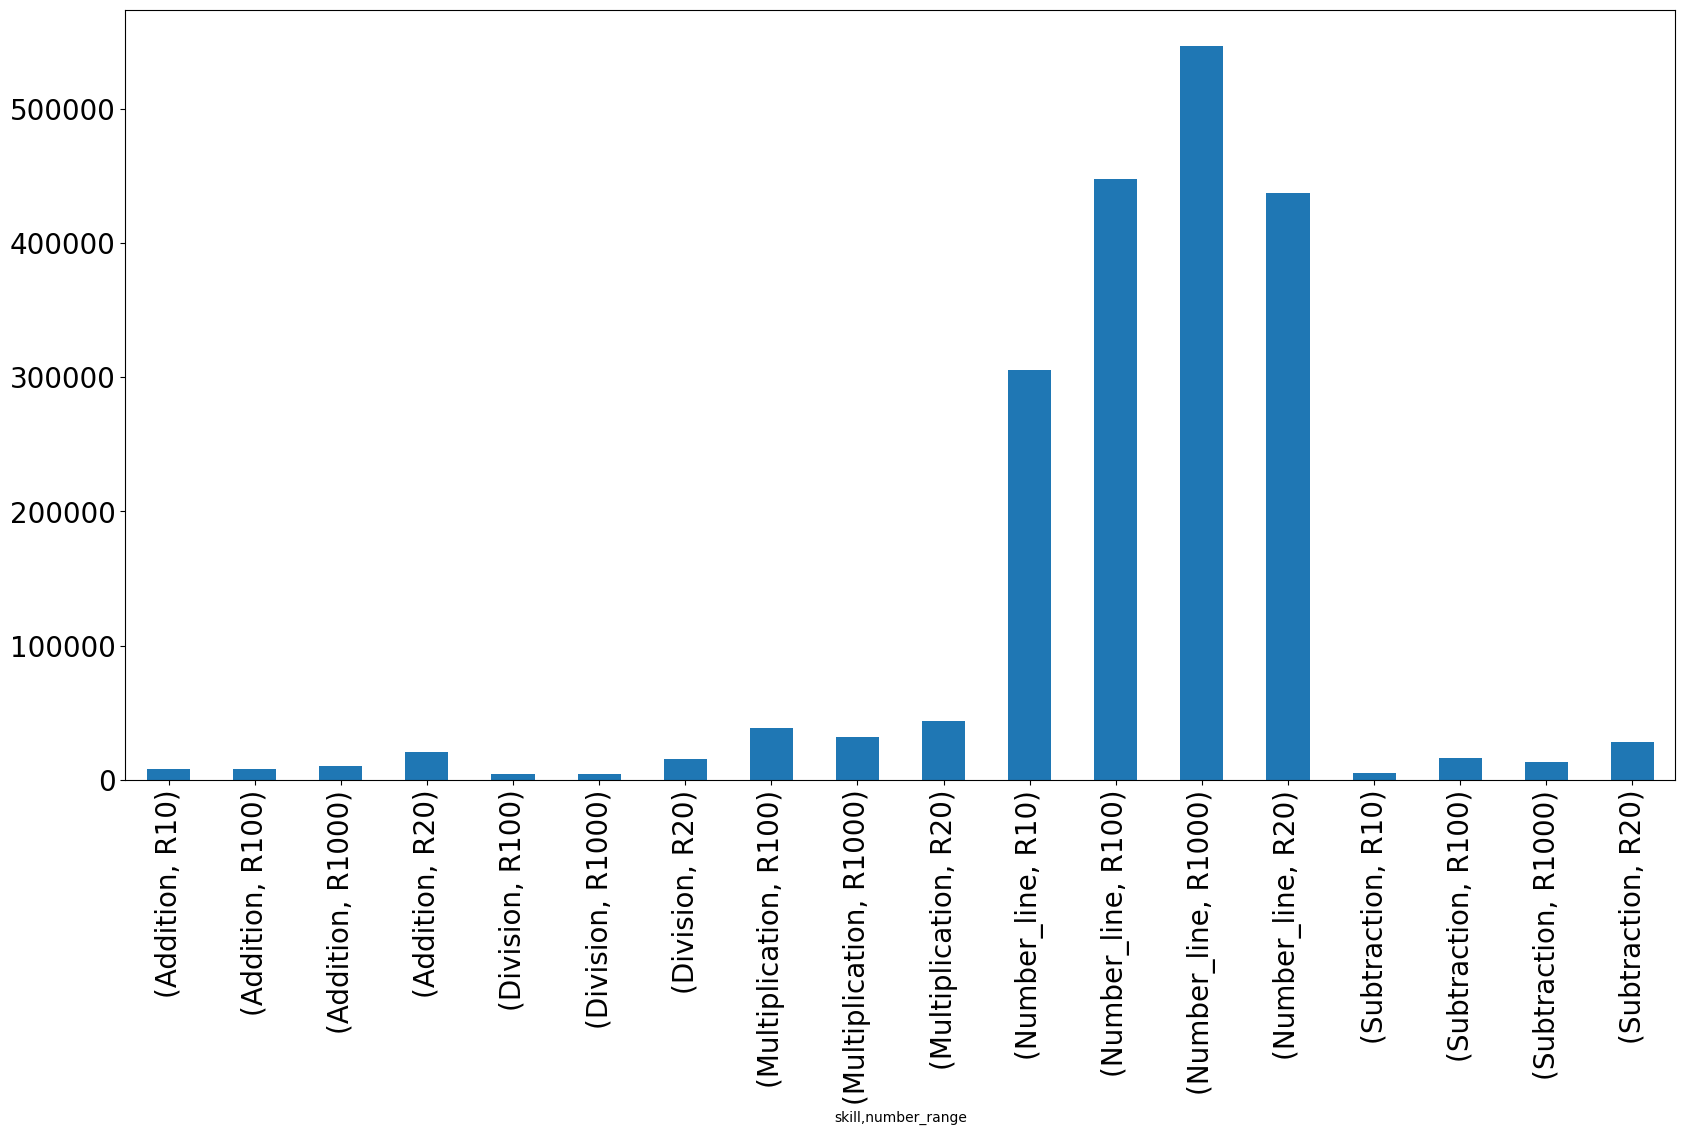

In [22]:
# Group df_subtasks by skill and number_range
df_subtasks_grouped = subtasks_pre.groupby(['skill', 'number_range'])

# count frequency of each skill and number_range of df_subtasks_grouped
df_subtasks_grouped_count = df_subtasks_grouped.count()

# plot df_subtasks_grouped_count as bar plot keep only user_id column
df_subtasks_grouped_count['user_id'].plot(kind='bar', figsize=(20, 10), fontsize=20)

**Users processing**

In [23]:
print(users.index.is_unique)
print("We have {} distinct users".format(len(users.index)))

True
We have 64932 distinct users


In [24]:
users.isna().any()

learning_time_ms     False
logged_in_time_ms    False
language              True
country               True
start                False
end                  False
dtype: bool

In [25]:
users=users.dropna()
print("We now have {} users".format(len(users.index)))

We now have 48778 users


In [27]:
def report_scores(events_pre,subtasks_pre,index,scaled=False) :
    '''This function returns the scores earned by each user in each skill and each range'''
    score_metric = 'scaled_score_score' if scaled else 'score'
    #sum up earned scores in each skill and each range
    res=subtasks_pre.groupby(['user_id', 'skill','number_range'])['score'].sum().to_frame()
    #we devide by the maximum possible to earn score
    div=subtasks_pre.groupby(['user_id', 'skill','number_range'])['score'].count().to_frame()
    div=div.apply(lambda x : x*complexity_dict[x.name[2]],axis=1)
    w_score=res*100/div
    #min max scaling to scores
    w_score['scaled_score'] = (w_score['score'] - w_score['score'].min()) / (w_score['score'].max() - w_score['score'].min())
    #now we want to report all earned scores in a dictionnary for each user
    skills=events_pre.skill.unique() 
    scores= pd.DataFrame(index = index,columns=np.append(skills,'max_level_solved'))
    empty_scores = {c:0 for c in complexity_dict}
    empty_levels = {s:'R10' for s in skills}
    scores[skills]=scores[skills].apply(lambda x : [empty_scores.copy() for i in range(len(skills))],axis=1,result_type='expand')
    scores['max_level_solved']=scores['max_level_solved'].map(lambda x : empty_levels.copy())
    #get max level solved for each category
    highest=subtasks_pre[subtasks_pre.correct].groupby(['user_id','skill']).number_range.agg(lambda x : max(x,key=lambda s : int(s.split('R')[1]))).rename('max_level_attempted')
    #report max level
    for k,v in highest.to_dict().items() : 
        scores.loc[k[0]]['max_level_solved'][k[1]]=v
    #report scores
    for k,v in w_score.to_dict(orient='index').items():
        scores.loc[k[0]][k[1]][k[2]]=v[score_metric]
    return scores

In [28]:
def process_users(users,events_pre,subtasks_pre) :
    '''This function takes as input the target users, events_pre and subtasks_pre dataframes 
    returns users table with features of our interest'''
    #learning_time of each user
    learning_time = users.learning_time_ms
    #locality of each user
    ui_locale=users.country.rename("ui_locale")
    #events per user, we only have games in our events
    num_games=events_pre.reset_index().groupby('user_id').user_id.count().rename("number_of_games")
    #number of answers per users
    total_answers=subtasks_pre.groupby('user_id').user_id.count().rename("number_of_games")
    #computing the absolute percentage of correct answers per user
    abs_perc_correct=subtasks_pre.groupby('user_id').correct.apply(lambda x : (x==True).sum())
    abs_perc_correct= (abs_perc_correct*100/total_answers).rename("absolute_percentage_correct")
    #compute weighted scores and max level solved for each skill 
    w_score=report_scores(events_pre,subtasks_pre,ui_locale.index)
    #compute free training usage
    free_tr=events_pre[events_pre['mode']=='FREE_TRAINING'].groupby('user_id').learning_time_ms.agg(sum).rename('total_free_training_time_ms')
    users_pre=pd.concat([ui_locale,num_games,learning_time,abs_perc_correct,free_tr,w_score],axis=1).fillna(0)
    return users_pre

These defined function will allow us to form a final user table (for each chosen threshhold) that hold all needed features for each user

In [29]:
thresh = 5
with open('data/events_pre{}.pkl'.format(thresh), 'rb') as f:
    events_pre = pickle.load(f)
with open('data/subtasks_pre{}.pkl'.format(thresh), 'rb') as f:
    subtasks_pre = pickle.load(f)
#we are only interested on users that actually performed enough events wrt to our threshhold
filtered_users=users[users.index.isin(events_pre.index.get_level_values('user_id'))]
#we can process form our final user table
users_pre=process_users(filtered_users,events_pre,subtasks_pre)
filtered_users_pre = users_pre[users_pre.number_of_games>thresh]
print("Length of table for users who played more than {} games : {}".format(thresh,len(filtered_users_pre.index)))
filtered_users_pre.to_pickle('data/users_pre{}.pkl'.format(thresh))

Length of table for users who played more than 5 games : 33876


In [30]:
#example of user_pre entries
users_pre.head()

,ui_locale,number_of_games,learning_time_ms,absolute_percentage_correct,total_free_training_time_ms,Number_line,Addition,Subtraction,Division,Multiplication,max_level_solved
user_id,,,,,,,,,,,
2,NL,258,188171589,82.30958,"458,409.00000","{'R10': 86.20689655172414, 'R20': 100.0, 'R100...","{'R10': 0, 'R20': 100.0, 'R100': 0.0, 'R1000': 0}","{'R10': 0, 'R20': 0, 'R100': 100.0, 'R1000': 5...","{'R10': 0, 'R20': 40.0, 'R100': 100.0, 'R1000'...","{'R10': 0, 'R20': 0, 'R100': 100.0, 'R1000': 9...","{'Number_line': 'R1000', 'Addition': 'R20', 'S..."
4,CH,77,73967025,75.72816,0.00000,"{'R10': 62.5, 'R20': 80.0, 'R100': 76.92307692...","{'R10': 0, 'R20': 0, 'R100': 0, 'R1000': 0}","{'R10': 0, 'R20': 33.333333333333336, 'R100': ...","{'R10': 0, 'R20': 0, 'R100': 0, 'R1000': 0}","{'R10': 0, 'R20': 100.0, 'R100': 0, 'R1000': 0}","{'Number_line': 'R100', 'Addition': 'R10', 'Su..."
5,CH,41,41135378,82.35294,"49,893.00000","{'R10': 66.66666666666667, 'R20': 100.0, 'R100...","{'R10': 100.0, 'R20': 100.0, 'R100': 0, 'R1000...","{'R10': 0, 'R20': 0, 'R100': 100.0, 'R1000': 1...","{'R10': 0, 'R20': 0, 'R100': 0, 'R1000': 0}","{'R10': 0, 'R20': 0, 'R100': 100.0, 'R1000': 0}","{'Number_line': 'R1000', 'Addition': 'R20', 'S..."
6,CH,37,37110540,94.87179,0.00000,"{'R10': 75.0, 'R20': 88.88888888888889, 'R100'...","{'R10': 0, 'R20': 0, 'R100': 0, 'R1000': 0}","{'R10': 0, 'R20': 0, 'R100': 0.0, 'R1000': 0}","{'R10': 0, 'R20': 100.0, 'R100': 0, 'R1000': 0}","{'R10': 0, 'R20': 100.0, 'R100': 0, 'R1000': 0}","{'Number_line': 'R100', 'Addition': 'R10', 'Su..."
10,NL,19,24439636,47.36842,0.00000,"{'R10': 16.666666666666668, 'R20': 61.53846153...","{'R10': 0, 'R20': 0, 'R100': 0, 'R1000': 0}","{'R10': 0, 'R20': 0, 'R100': 0, 'R1000': 0}","{'R10': 0, 'R20': 0, 'R100': 0, 'R1000': 0}","{'R10': 0, 'R20': 0, 'R100': 0, 'R1000': 0}","{'Number_line': 'R20', 'Addition': 'R10', 'Sub..."


**We want to provide a visualization for a user's current level and strengths as a chart**

In [31]:
def visualize_radio_chart(df, student_id):
    interm = df.loc[student_id] 
    categories = ['{} {}'.format(m,n) for m,n in zip(interm.max_level_solved.keys(),interm.max_level_solved.values())] 
    student_scores = [interm[c][v] for c,v in zip(interm.max_level_solved.keys(),interm.max_level_solved.values())]
    student_scores += [student_scores[0]]

    fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True))
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_rlabel_position(0)
    plt.xticks(np.linspace(0, 2*np.pi, len(categories) + 1)[:-1], categories)

    plt.plot(np.linspace(0, 2*np.pi, len(categories) + 1), student_scores)
    plt.fill(np.linspace(0, 2*np.pi, len(categories) + 1), student_scores, alpha=0.2)
    
    plt.title("user {} performance chart".format(student_id))
    plt.tight_layout()
    plt.show()

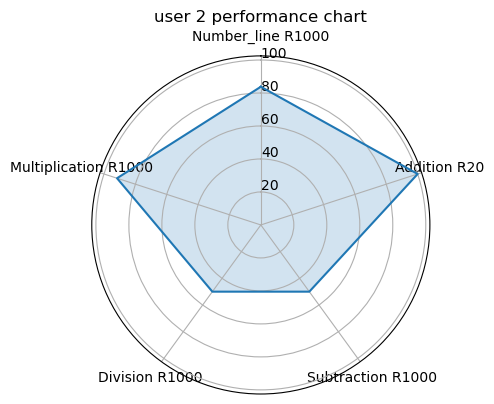

In [32]:
visualize_radio_chart(users_pre, 2)

## BKT : Model Building

In the following section we train 3 BKT models to predict user performance accross skills.


In [2]:
# Read data from pkl file
df_subtasks = pd.read_pickle('data/subtasks_pre5.pkl')
# Create mapping column for skill 
col_names = { "skill" : "skill_name"}
df_subtasks.skill_id = df_subtasks.skill_id.astype(int)
df_subtasks.correct = df_subtasks.correct.astype(int)
df_subtasks.rename(columns=col_names, inplace=True)
df_subtasks.reset_index(inplace=True)
prior_success=df_subtasks.groupby(['user_id','skill_name','number_range'])[['subtask_id','correct']].agg({'correct':lambda x : [xi if xi==0 else xi-1 for xi in np.cumsum(x)] ,'subtask_id':list}).explode(['subtask_id','correct']).reset_index(drop=True)
prior_success=prior_success.rename({'correct':'prior_success'}, axis=1)
df_subtasks = df_subtasks.merge(prior_success, on=['subtask_id'])
df_subtasks.head()


,subtask_id,event_id,user_id,mode,game_name,learning_time_ms,subtasks,number_range,start,end,skill_id,type,score,sub_types,skill_name,correct,prior_success
0,0,1,2,NORMAL,Subitizing,"13,094.00000","{'hasProperResult': True, 'range': 'R10', 'cor...",R10,2020-08-20T07:13:50.876Z,2020-08-20T07:14:30.108Z,1,task,0,ConciseSubitizingTaskDescription,Number_line,0,0
1,1,3,2,NORMAL,Conversion,"15,879.00000","{'answer': 6, 'range': 'R10', 'correct': True,...",R10,2020-08-21T07:02:20.112Z,2020-08-21T07:02:36.221Z,3,task,1,ConciseConversionTaskDescription,Number_line,1,0
2,2,4,2,NORMAL,Landing,"6,075.00000","{'range': 'R10', 'correct': True, 'lowerBound'...",R10,2020-08-24T07:02:59.855Z,2020-08-24T07:03:07.382Z,18,task,1,ConciseLandingTaskDescription,Number_line,1,1
3,3,5,2,NORMAL,Landing,"6,910.00000","{'range': 'R10', 'correct': True, 'lowerBound'...",R10,2020-08-26T06:47:21.504Z,2020-08-26T06:47:30.050Z,19,task,1,ConciseLandingTaskDescription,Number_line,1,2
4,4,6,2,NORMAL,Calculator,"7,507.00000","{'range': 'R20', 'answerMode': 'RESULT', 'corr...",R20,2020-08-26T07:20:58.766Z,2020-08-26T07:21:06.439Z,54,task,2,ConciseEquationTaskDescription,Addition,1,0


In [3]:
subtasks_bkt = df_subtasks.copy()
subtasks_bkt.skill_id = subtasks_bkt.skill_id.astype(int)
subtasks_bkt = subtasks_bkt[['skill_id','user_id','event_id','subtask_id','skill_name','number_range','correct','prior_success']]
subtasks_bkt.head()

,skill_id,user_id,event_id,subtask_id,skill_name,number_range,correct,prior_success
0,1,2,1,0,Number_line,R10,0,0
1,3,2,3,1,Number_line,R10,1,0
2,18,2,4,2,Number_line,R10,1,1
3,19,2,5,3,Number_line,R10,1,2
4,54,2,6,4,Addition,R20,1,0


In [4]:
#Skill set and Difficulty number set
skill_names = subtasks_bkt['skill_name'].unique()
num_range_names = subtasks_bkt['number_range'].unique()

# Pretty print skill_names and num_range_names
pp.pprint(skill_names)
pp.pprint(num_range_names)
# Params
seed , num_fits = 0, 5


array(['Number_line', 'Addition', 'Subtraction', 'Division',
       'Multiplication'], dtype=object)
array(['R10', 'R20', 'R100', 'R1000'], dtype=object)


In this section, we train our models on the whole data to see how well it understands it. We will compare in the uupcoming section training and testing accuracies. For now, we save the models for future sage. <br>
Average training time for each model is 3h.

**1st BKT Model**

We train 4 BKT Models corresponding to each difficulty range with multilearn on skill_id. This model tries to grasp how an average student would learn a given skill in given difficulty.


In [78]:
for num_range in num_range_names:
    df_range = subtasks_bkt[(subtasks_bkt['number_range'] == num_range)]
    
    # Check if df_range is empty
    if df_range.empty:
        continue
    
    model = Model(seed=seed, num_fits=num_fits)
    model.fit(data = df_range, skills=skill_names, forgets=True,  multilearn='skill_id')
    model.save(f'models/all_data/skill_id/model_{num_range}.pkl')

**2nd BKT Model**

Now we will train a BKT Model accross weeks.
The training was done for each clustered skill (Addition, Multiplication, ...) and on each number range difficulty, the models are all multi-learning (users) on clustered skill tasks. This model tries to grasp how a does a specific user learn in a specific skill and diffclty.

There was a total of 4 * 5 - 1 = 29 models trained, (-1) accounting for no Division R10 skills.   
First, we will need to process our subtasks weekly.


In [5]:
subtasks_pre=df_subtasks.copy()
subtasks_pre['finished_timestamp']=subtasks_pre['subtasks'].apply(lambda x : x['subtask_finished_timestamp'])
subtasks_pre=subtasks_pre.dropna(subset=['finished_timestamp'])
subtasks_pre=subtasks_pre[['skill_id','user_id','event_id','subtask_id','skill_name','number_range','correct','finished_timestamp']].reset_index(drop=True)
subtasks_pre.head()

,skill_id,user_id,event_id,subtask_id,skill_name,number_range,correct,finished_timestamp
0,1,2,1,0,Number_line,R10,0,2020-08-20T07:14:29.954Z
1,3,2,3,1,Number_line,R10,1,2020-08-21T07:02:35.954Z
2,18,2,4,2,Number_line,R10,1,2020-08-24T07:03:07.167Z
3,19,2,5,3,Number_line,R10,1,2020-08-26T06:47:29.872Z
4,54,2,6,4,Addition,R20,1,2020-08-26T07:21:06.237Z


In [6]:
def add_week(df_start,timestamp_name):
    df_week = df_start.copy().dropna(subset=timestamp_name)
    df_week[timestamp_name]=pd.to_datetime(df_week[timestamp_name])
    #new column describing week of completion
    df_week['week']=df_week[timestamp_name].apply(lambda x : [x.isocalendar().week,x.isocalendar().year])
    return df_week

def process_week(df_week,first_week_users):
    #add the first week each user solved a task
    df_week=df_week.join(first_week_users,on='user_id',rsuffix='0',how='inner')
    #shift weeks for each specific user
    df_week['week']=df_week[['week','week0']].apply(lambda x: x['week'][0]-x['week0'][0]+(x['week'][1]-x['week0'][1])*52,axis=1)
    return df_week.drop('week0',axis=1)

In [7]:
#add a column week for each row
subtasks_week=add_week(subtasks_pre,'finished_timestamp')
#get the first week each user solved a task
first_week_users = subtasks_week.groupby('user_id').week.first()
#shift column week with respect to week0 of each user
subtasks_week=process_week(subtasks_week,first_week_users)
subtasks_week.head()

,skill_id,user_id,event_id,subtask_id,skill_name,number_range,correct,finished_timestamp,week
0,1,2,1,0,Number_line,R10,0,2020-08-20 07:14:29.954000+00:00,0
1,3,2,3,1,Number_line,R10,1,2020-08-21 07:02:35.954000+00:00,0
2,18,2,4,2,Number_line,R10,1,2020-08-24 07:03:07.167000+00:00,1
3,19,2,5,3,Number_line,R10,1,2020-08-26 06:47:29.872000+00:00,1
4,54,2,6,4,Addition,R20,1,2020-08-26 07:21:06.237000+00:00,1


count   34,566.00000
mean        57.01982
std         66.17816
min          1.00000
25%         15.00000
50%         34.00000
75%         73.00000
max      1,216.00000
Name: correct, dtype: float64


<AxesSubplot:>

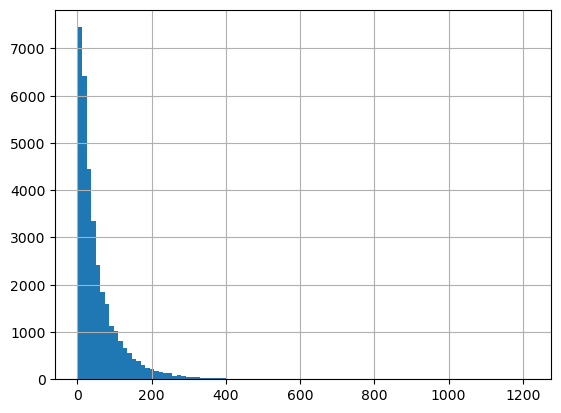

In [8]:
#visualize a plot for the average number subtasks for each user
w=subtasks_week.groupby('user_id').correct.count()
print(w.describe())
w.hist(bins=100)

Hence we will fix a threshhold of 50 subtasks to be considered as an active user.

In [83]:
skill_num_range_pairs = [(skill, num_range) for skill in skill_names for num_range in num_range_names]
for skill, num_range in skill_num_range_pairs[::-1]:
    df_skill = subtasks_week[(subtasks_week['skill_name'] == skill) & (subtasks_week['number_range'] == num_range)]
    #only keep users with at least 50 subtasks in this category
    s=df_skill.groupby(['user_id']).size()>=50 
    df_skill=df_skill[df_skill.user_id.isin(s[s].index)]

    if df_skill.empty:
        continue

    defaults = {'assistment_id':'event_id','template_id':'skill_id', 'order_id':'subtask_id'}
    model = Model(seed=seed, num_fits=num_fits,defaults=defaults)
    model.fit(data=df_skill, skills=skill, forgets=True, multilearn='user_id',defaults=defaults)
    model.save(f'models/all_data/user_id/model_{skill}_{num_range}.pkl')

## BKT : Model Evaluation
The  previously saved models encapsulate all the needed informations for knowledge tracing including learing, forgetting, prior knowledge probabilities.
Now we will try to evaluate our models first on the whole data using our previously trained model, then on train-test split basis of 80%,20%.   
We define some functions for modularity.

In [31]:
from pandas.core.frame import DataFrame
import os 

def models_path(folder: str = 'models/fit_1', seed: int = 0) -> DataFrame:
     """Create a dataframe with the  skill name, number rannge and the pre-trained model as well

     Args:
         folder (str, optional): folder were all the fit models are saved. Defaults to 'models/fit_1'.
         seed (int, optional): seed that was used to fit the models. Defaults to 0.

     Returns:
         DataFrame: _description_
     """
     paths = [os.path.join(folder, file) for file in os.listdir(folder)]
     ranges = [path.removesuffix('.pkl').split('_')[-1] for path in paths]
     skills = [path.removesuffix('.pkl').split('_')[-2] for path in paths]
     
     # map skills if is "line" to "Number_line"
     skills = ['Number_line' if skill == 'line' else skill for skill in skills]
     
     models=[]
     for model_path in paths:
          model = Model(seed=seed)
          model.load(model_path)
          models.append(model)
     
     
     # Create dataframe  indexed with ranges and skill with column path 
     df_paths = pd.DataFrame({'model': models}, index=[skills, ranges])
     
     #Rename index of value "line" to "Number_line"
     df_paths.index.names = ['skill_name', 'number_range']

     return df_paths

In [83]:
def get_train_data(df_data, num_range, thresh=50, skill=None, weeks=False, range=False) :
    if range :
        df_filtered = df_data[df_data['number_range'] == num_range]
    elif weeks: 
        df_filtered = df_data[(df_data['skill_name'] == skill) & (df_data['number_range'] == num_range)]
        s=df_filtered.groupby(['user_id']).size()>=thresh 
        df_filtered=df_filtered[df_filtered.user_id.isin(s[s].index)]
    return df_filtered

In [285]:
def get_test_data(df_data, num_range=None, thresh=50, skill=None, skill_id=None, user_id = None,weeks=False, specific=False):
    if weeks : 
        df_filtered = df_data[(df_data['skill_name'] == skill) & (df_data['number_range'] == num_range)]
        s=df_filtered.groupby(['user_id']).size()>=thresh 
        df_filtered=df_filtered[df_filtered.user_id.isin(s[s].index)]
        x_test  = df_filtered.groupby(['user_id']).apply(lambda x: x.tail(round(0.2*len(x)))).reset_index(drop=True)
        if specific :
            x_test = x_test[(x_test['skill_id'] == skill_id) & (x_test['user_id'] == user_id)]
    else : 
        df_filtered = df_data[df_data['number_range'] == num_range]
        val = round(len(df_filtered)*0.8)  
        x_test = df_filtered[val:]
        if specific : 
            x_test = x_test[(x_test['skill_id'] == skill_id) & (x_test['user_id'] == user_id)]
    return x_test

In [283]:
def evaluate(df_model, df_data, get_data, thresh=50, weeks=False, range=False) :
    for skill, num_range in df_model.index:
        model = df_model.loc[(skill, num_range), 'model']
        if range :
            data = get_data(df_data, num_range=num_range, range=True)
        elif weeks :
            data = get_data(df_data, num_range=num_range, skill=skill, weeks=True, thresh=thresh)
        auc = model.evaluate(data=data, metric='auc') 
        rmse = model.evaluate(data=data, metric='rmse')
        df_model.loc[(skill, num_range), 'auc'] = auc
        df_model.loc[(skill, num_range), 'rmse'] = rmse


In [373]:
def plots(df_model_skill,title,range=False):

    # Two bar plots for RMSE: first one with std (mean RMSE over all skills), then one bar plot with a bar for each specific skill
    fig, axes = plt.subplots(2, 1, figsize=(4,8))
    
    # select index skill
    df_model_skill = df_model_skill.reset_index()
    
    df_model_skill.index =  df_model_skill.number_range if range else df_model_skill.skill_name
    
    skills = df_model_skill.index.to_list()
    
    sns.barplot(ax=axes[0],x=skills, y=df_model_skill.rmse, estimator=np.mean, ci='sd')
    axes[0].set_title('RMSE across skills')
    axes[0].set_xlabel('', rotation=90)


    sns.barplot(ax=axes[1] ,x=skills, y=df_model_skill.auc,estimator=np.mean, ci='sd')
    axes[1].set_title('AUC across skills')
    axes[1].set_xlabel('', rotation=90)
    
    # rotate labels of x axis
    for ax in axes:
        ax.tick_params(axis='x', rotation=90)
        
    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    

**1st BKT Model**

Training Evaluation

In [353]:
#evaluate all_data fitted models
all_model_skills=models_path('models/all_data/skill_id')
evaluate(all_model_skills, subtasks_bkt, get_train_data, range=True)
all_model_skills

model  \
skill_name number_range                                                      
id\model   R10           Model(parallel=True, num_fits=5, seed=0, defau...   
           R100          Model(parallel=True, num_fits=5, seed=0, defau...   
           R1000         Model(parallel=True, num_fits=5, seed=0, defau...   
           R20           Model(parallel=True, num_fits=5, seed=0, defau...   

                            auc    rmse  
skill_name number_range                  
id\model   R10          0.69054 0.43444  
           R100         0.69363 0.40933  
           R1000        0.71324 0.34709  
           R20          0.63451 0.39841

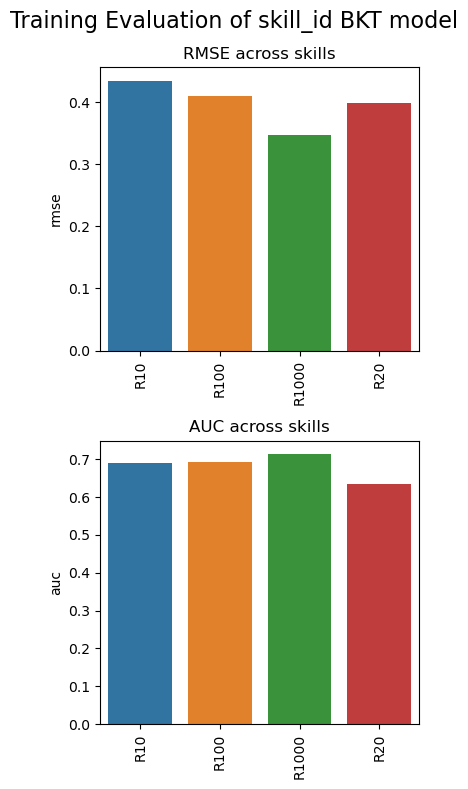

In [374]:
plots(all_model_skills,'Training Evaluation of skill_id BKT model',range=True)

As shown in the above plots we get a training precision of ~70% (auc) and an accuracy of ~40% (rmse) per difficulty with this model

In [50]:
for num_range in num_range_names:
    df_range = subtasks_bkt[(subtasks_bkt['number_range'] == num_range)]
    
    # Check if df_range is empty
    if df_range.empty:
        continue
    
    model = Model(seed=seed, num_fits=num_fits)
    #get 80% of the data for training
    val = round(len(df_range)*0.8)
    x_train = df_range[:val]
    model.fit(data = x_train, skills=skill_names, forgets=True,  multilearn='skill_id')
    model.save(f'models/split_data/skill_id/model_{num_range}.pkl')

In [284]:
#evaluate resulting skill_id models
split_model_skills=models_path('models/split_data/skill_id')
evaluate(split_model_skills, subtasks_bkt, get_test_data, range=True)
split_model_skills

model  \
skill_name number_range                                                      
id\model   R10           Model(parallel=True, num_fits=5, seed=0, defau...   
           R100          Model(parallel=True, num_fits=5, seed=0, defau...   
           R1000         Model(parallel=True, num_fits=5, seed=0, defau...   
           R20           Model(parallel=True, num_fits=5, seed=0, defau...   

                            auc    rmse  
skill_name number_range                  
id\model   R10          0.69757 0.43110  
           R100         0.69544 0.40675  
           R1000        0.71204 0.34653  
           R20          0.63174 0.39950

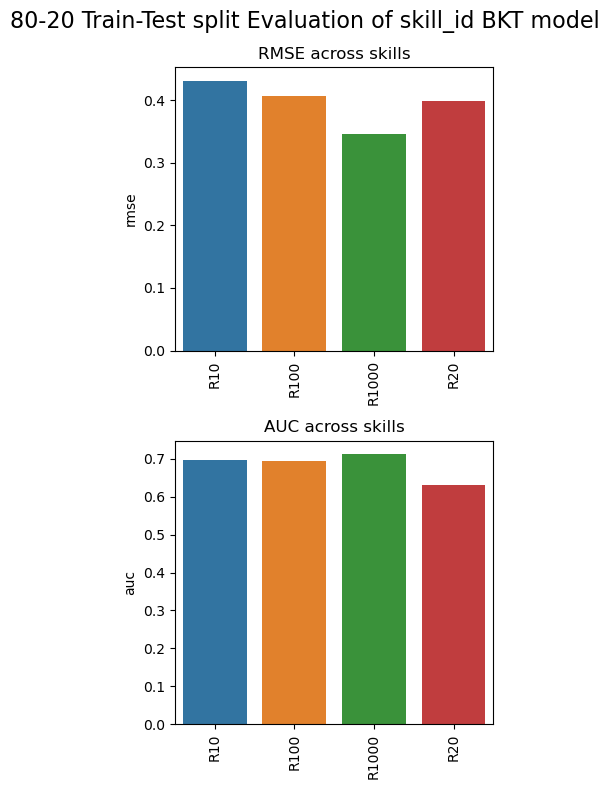

In [375]:
plots(split_model_skills,'80-20 Train-Test split Evaluation of skill_id BKT model ',range=True)

From the plots, we can see a training precision of ~70% (auc) and an accuracy of ~40% (rmse) per skill domain with this model.The testing evaluation is nearly the same as the training. It suggests that the model has generalized well from the training set to the unseen testing set. This means that the model is not overfitting.

**2nd BKT Model**

Training evaluation

In [155]:
#evaluate all_data fitted models
all_model_users50=models_path('models/all_data/user_id')
evaluate(all_model_users50, subtasks_week, get_train_data, weeks=True, thresh=50)
all_model_users50

model  \
skill_name     number_range                                                      
Addition       R1000         Model(parallel=True, num_fits=5, seed=0, defau...   
Division       R1000         Model(parallel=True, num_fits=5, seed=0, defau...   
Multiplication R100          Model(parallel=True, num_fits=5, seed=0, defau...   
               R1000         Model(parallel=True, num_fits=5, seed=0, defau...   
Number_line    R10           Model(parallel=True, num_fits=5, seed=0, defau...   
               R100          Model(parallel=True, num_fits=5, seed=0, defau...   
               R1000         Model(parallel=True, num_fits=5, seed=0, defau...   
               R20           Model(parallel=True, num_fits=5, seed=0, defau...   
Subtraction    R100          Model(parallel=True, num_fits=5, seed=0, defau...   
               R1000         Model(parallel=True, num_fits=5, seed=0, defau...   
               R20           Model(parallel=True, num_fits=5, seed=0, defau...   

                                auc    rmse  
skill_name     number_range                  
Addition       R1000        0.73271 0.45011  
Division       R1000        0.65091 0.47030  
Multiplication R100         0.68961 0.46674  
               R1000        0.70743 0.37045  
Number_line    R10          0.76942 0.36873  
               R100         0.69435 0.40668  
               R1000        0.70063 0.33092  
               R20          0.66939 0.38231  
Subtraction    R100         0.70483 0.46174  
               R1000        0.65521 0.47331  
               R20          0.71097 0.46348

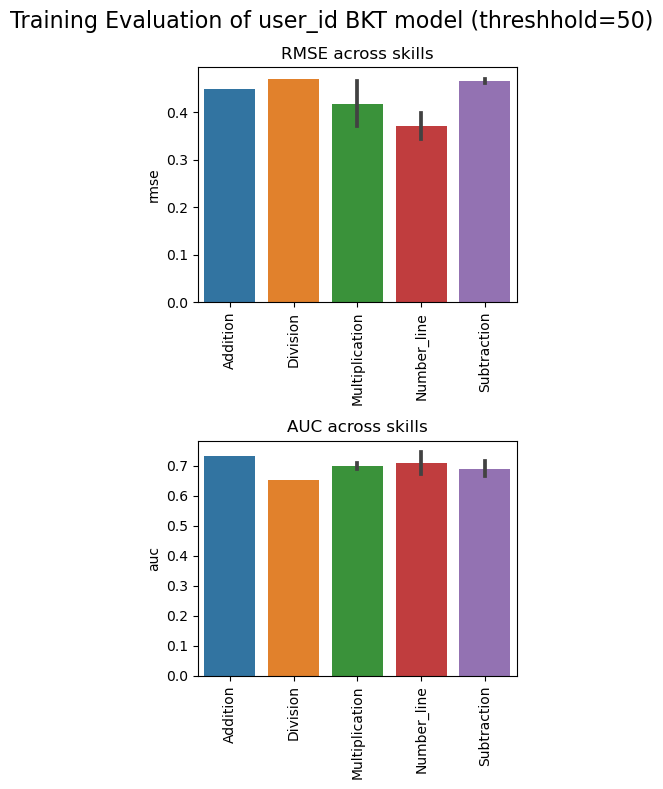

In [376]:
plots(all_model_users50,'Training Evaluation of user_id BKT model (threshhold=50)')

From the plots, we can see a training precision of ~70% (auc) and an accuracy of ~40% (rmse) per skill domain with this model

Train-test split Evaluation

We train as well on 80% of the data. Since the data was ordered by weeks for each user, week 0 being his own starting week, we will consider 80% of the data for each user for training. The remaining 20% will be used for testing.      
The data being unbalanced accross users, we will run 2 episodes, considering for the first one a threshhold of 50 subtasks performed for the first one while we consider 100 for the latter to try to improve accuracy. Some skills and ranges may not be able to produce a model given these constraints, we will ignore them.

In [108]:
for thresh in [50,100] :
    for skill, num_range in skill_num_range_pairs[::-1]:
        df_skill = subtasks_week[(subtasks_week['skill_name'] == skill) & (subtasks_week['number_range'] == num_range)]
    
        #only keep users with at least thresh subtasks in this category
        s=df_skill.groupby(['user_id']).size()>=thresh 
        df_skill=df_skill[df_skill.user_id.isin(s[s].index)]

        if df_skill.empty:
            continue
        
        #for each user we get 80% of his data for training
        x_train = df_skill.groupby(['user_id']).apply(lambda x: x.head(round(0.8*len(x)))).reset_index(drop=True)
        defaults = {'assistment_id':'event_id','template_id':'skill_id', 'order_id':'subtask_id'}
        model = Model(seed=seed, num_fits=num_fits,defaults=defaults)
        model.fit(data=x_train, skills=skill, forgets=True, multilearn='user_id',defaults=defaults)
        model.save(f'models/split_data/users/thresh_{thresh}/model_{skill}_{num_range}.pkl')

In [150]:
#evaluate resulting thresh=50 models
split_model_users50=models_path('models/split_data/user_id/thresh_50')
evaluate(split_model_users50, subtasks_week, get_test_data, weeks=True, thresh=50)
split_model_users50

model  \
skill_name     number_range                                                      
Addition       R1000         Model(parallel=True, num_fits=5, seed=0, defau...   
Division       R1000         Model(parallel=True, num_fits=5, seed=0, defau...   
Multiplication R100          Model(parallel=True, num_fits=5, seed=0, defau...   
               R1000         Model(parallel=True, num_fits=5, seed=0, defau...   
Number_line    R10           Model(parallel=True, num_fits=5, seed=0, defau...   
               R100          Model(parallel=True, num_fits=5, seed=0, defau...   
               R1000         Model(parallel=True, num_fits=5, seed=0, defau...   
               R20           Model(parallel=True, num_fits=5, seed=0, defau...   
Subtraction    R100          Model(parallel=True, num_fits=5, seed=0, defau...   
               R1000         Model(parallel=True, num_fits=5, seed=0, defau...   
               R20           Model(parallel=True, num_fits=5, seed=0, defau...   

                                auc    rmse  
skill_name     number_range                  
Addition       R1000        0.58214 0.50161  
Division       R1000        0.74013 0.49748  
Multiplication R100         0.56357 0.46320  
               R1000        0.48060 0.34030  
Number_line    R10          0.70772 0.36724  
               R100         0.58798 0.41337  
               R1000        0.58515 0.34171  
               R20          0.56236 0.38392  
Subtraction    R100         0.57327 0.51314  
               R1000        0.60963 0.47918  
               R20          0.66332 0.47598

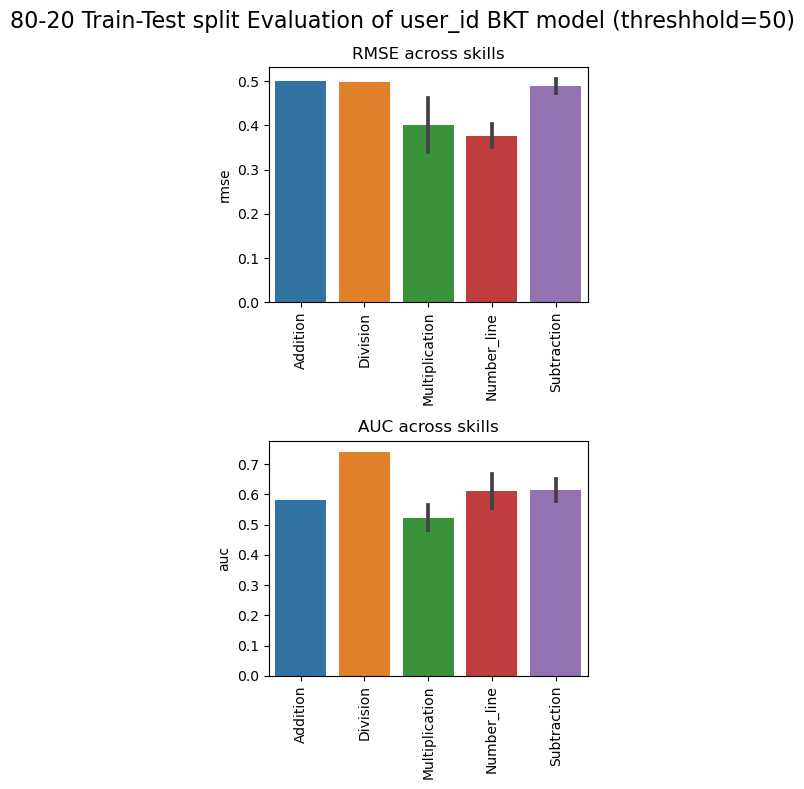

In [377]:
plots(split_model_users50,'80-20 Train-Test split Evaluation of user_id BKT model (threshhold=50)')

We can see that the precision gets lower for testing. It suggest that the training data might not be representative of the entire dataset, or it may lack sufficient diversity in terms of the variations and patterns present in the whole data. This can be explained by the fact that we took the remaining 20% data as time series sample. A user might have tackled different skills in the testing set than in the training set. 

In [106]:
#evaluate resulting thresh=100 models
split_model_users100=models_path('models/split_data/user_id/thresh_100')
evaluate(split_model_users100, subtasks_week, get_test_data, weeks=True, thresh=100)
split_model_users100

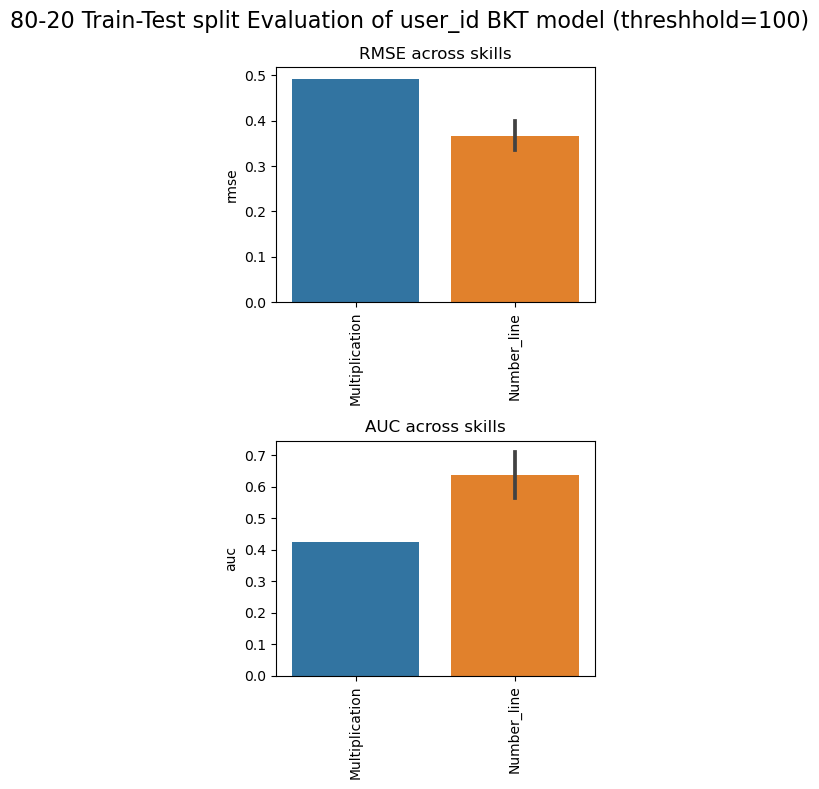

In [378]:
plots(split_model_users100,'80-20 Train-Test split Evaluation of user_id BKT model (threshhold=100)')

Number Line category got better results with a higher threshhold. Howver it is not the case for Number_line. This can be explained by the fact that Number_line is the most dense category in our data, hence it is more likely to have a higher threshhold of subtasks performed. On the other hand Multiplication is probably under represented in our data.

### We proceed to show some plots about predicting user skill response

In [287]:
id_map = pd.read_pickle('data/id_map.pkl')
id_map 

,label,skill_name,number_range
skill_id,,,
0,0-10 Concrete,Number_line,R10
1,0-10 Subitizing,Number_line,R10
2,0-10 Verbal,Number_line,R10
3,0-10 Concrete -> Arabic,Number_line,R10
4,0-10 Verbal -> Arabic,Number_line,R10
...,...,...,...
248,0-1000 Free Division Calculation,Division,R1000
249,0-1000 Free Division by Multiplication Calcula...,Division,R1000
250,0-1000 Free Multiplication Calculation,Multiplication,R1000


In [486]:
def predict_user_performance(df_subtasks: DataFrame,df_model_skill : DataFrame, user_id: int, skill_id: int, by_range =False):
    """Predict a user performance for a given skill_id using the pre-trained model

    Args:
        df_subtasks (DataFrame): dataframe of all subtasks  
        user_id (int): user
        skill_id (int): specific skill

    Returns:
        _type_: _description_
    """
    # Get key from value skill_id in skill_ids_map
    skill = id_map.loc[(skill_id), 'skill_name']
    label = id_map.loc[(skill_id), 'label']
    
    number_range = id_map.loc[(skill_id), 'number_range']
    # Get user data for skill_id
    if by_range:
        df_user = get_test_data(df_subtasks, num_range=number_range, user_id=user_id, skill_id=skill_id, specific=True)
    else :
        df_user = get_test_data(df_subtasks, num_range=number_range, skill=skill, user_id=user_id, skill_id=skill_id, weeks=True, specific=True)
    
    if df_user.empty:
        return None, None, None
    
    # Get model for skill_id
    if by_range : 
        model = df_model_skill.loc[('id\model', number_range), 'model']
    else :
        model = df_model_skill.loc[(skill, number_range), 'model']
    # Get predictions for user_id
    predictions = np.array(model.predict(data=df_user)['correct_predictions'])
    true_values = np.array(df_user['correct'])
    
    # Compute mse, auc and rmse
    mse = ((predictions - true_values) ** 2).mean()
    auc = model.evaluate(data=df_user, metric='auc')
    rmse = model.evaluate(data=df_user, metric='rmse')

    
    print(f'{skill=} {skill_id=} {mse=} {auc=} {rmse=}')
    
    # Plot predictions and true values
    plt.figure(figsize=(10, 5))
    plt.plot(predictions, label='predictions')
    plt.plot(true_values, label='true values')

    plt.title(f'User {user_id} | Task: {label} | Skill : {skill} | Number Range: {number_range}')
    plt.legend()
    plt.show()
    
    return mse, predictions, true_values, auc, rmse

We predict the performance of a user in a more specific skill (skill deeper than the general category). We feed the 20% test data to be predicted. We will try to compare both BKT models in most popular skills among users.

In [488]:
dfs_users=[]
for x in ['skill_id','user_id'] :
    if x == 'skill_id' :
        df_data = subtasks_bkt
    else :
        df_data = subtasks_week
    user_skill = df_data.groupby(['user_id'])['skill_id'].agg(pd.Series.mode)
    freqs = df_data.groupby(['user_id'])['skill_id'].count()
    df_user_skill = pd.DataFrame({'skill_id':user_skill.values, 'frequency':freqs.values}, index=user_skill.index)

    # Order by frequency
    df_user_skill = df_user_skill.sort_values(by=['frequency'], ascending=False)
    dfs_users.append(df_user_skill)

## SKILL ID MODEL

skill='Number_line' skill_id=107 mse=0.06945417948638995 auc=0.2979452054794521 rmse=0.26354160864347387


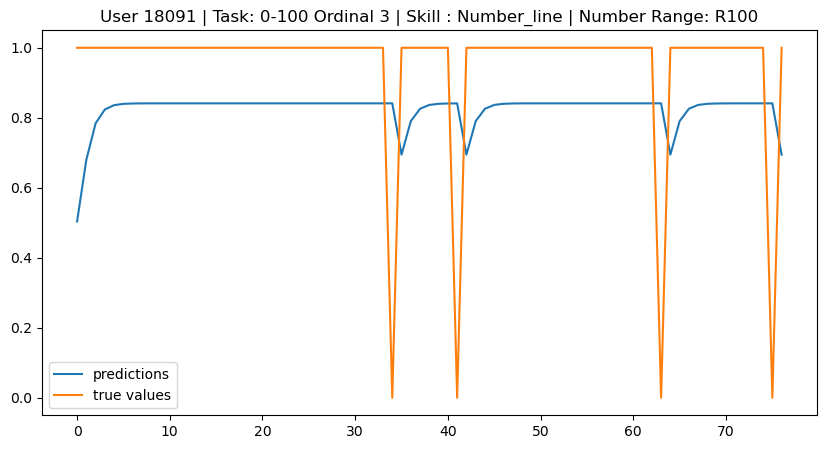

In [489]:
# Predictions for most frequent skill
df_user_skill = dfs_users[0]
for user in df_user_skill.head(1).index:
    skill_id = df_user_skill.loc[user, 'skill_id']
    predict_user_performance(subtasks_bkt, split_model_users50, user, skill_id=skill_id)

## BKT Model

skill='Number_line' skill_id=178 mse=0.013108796765583219 auc=0.7048004987531172 rmse=0.11449365382231178


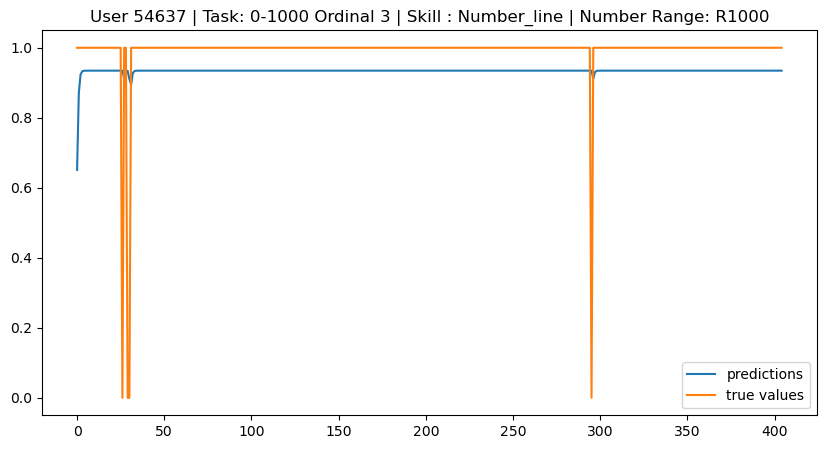

In [490]:
# Predictions for users with most frequent skill
df_user_skill = dfs_users[1]
for user in df_user_skill.head(2).index:
    skill_id = df_user_skill.loc[user, 'skill_id']
    predict_user_performance(subtasks_bkt, split_model_skills, user, skill_id,by_range=True)

It looks like the most popular skill is Ordinal 3 with diffictly range 1000, our Number_line R1000 model predicts that most learners achieve mastering of this basic skill with high probability of having learning that skill. 

In conclusion, our models performed well overall.    
We can see that the the skill_id model was less affected by the threshhold of subtasks performed. This can be explained by the fact that the skill_id model is more general and tries to grasp how an average student would learn a given skill in given difficulty and hand a better average accuracy.    
On the other hand, the user_id model is more specific and tries to grasp how a does a specific user learn in a specific skill and diffculty. However it achieved higher best accuracies in some skills. This could hint to fine tune a model for each user, which would be costly in terms of time and resources.

After trying to fit a model on free_training users versus those whon don't, we came to the conclusion that the data is too unbalanced to be able to fit a model on it. We would need to have more data about free_training users to be able to do so. Hence, we decide to perform an observational study

## Observational Study : Model Building



**Second research question : Do students who use free training peform better or worse than those who don't**

In [492]:
import pickle
with open('data/users_pre5.pkl', 'rb') as f:
    users_pre = pickle.load(f)
skills= ['Number_line', 'Addition', 'Subtraction', 'Division', 'Multiplication']
complexity_dict = {'R10': 1, 'R20': 2, 'R100': 10, 'R1000': 100}
#Here we encode max_level_solved for each skil to be able to use this feature for propensity score computing
for s in skills :
    users_pre[s+'_level']=users_pre.max_level_solved.map(lambda x : complexity_dict[x[s]])
users_pre.head(2)

,ui_locale,number_of_games,learning_time_ms,absolute_percentage_correct,total_free_training_time_ms,Number_line,Addition,Subtraction,Division,Multiplication,max_level_solved,Number_line_level,Addition_level,Subtraction_level,Division_level,Multiplication_level
user_id,,,,,,,,,,,,,,,,
2,NL,258,188171589,82.30958,"458,409.00000","{'R10': 86.20689655172414, 'R20': 100.0, 'R100...","{'R10': 0, 'R20': 100.0, 'R100': 0.0, 'R1000': 0}","{'R10': 0, 'R20': 0, 'R100': 100.0, 'R1000': 5...","{'R10': 0, 'R20': 40.0, 'R100': 100.0, 'R1000'...","{'R10': 0, 'R20': 0, 'R100': 100.0, 'R1000': 9...","{'Number_line': 'R1000', 'Addition': 'R20', 'S...",100,2,100,100,100
4,CH,77,73967025,75.72816,0.00000,"{'R10': 62.5, 'R20': 80.0, 'R100': 76.92307692...","{'R10': 0, 'R20': 0, 'R100': 0, 'R1000': 0}","{'R10': 0, 'R20': 33.333333333333336, 'R100': ...","{'R10': 0, 'R20': 0, 'R100': 0, 'R1000': 0}","{'R10': 0, 'R20': 100.0, 'R100': 0, 'R1000': 0}","{'Number_line': 'R100', 'Addition': 'R10', 'Su...",10,1,2,1,2


In [493]:
df=users_pre.copy()
df['total_free_training_time_ms'][df['total_free_training_time_ms']>0].describe()

count       7,160.00000
mean      170,189.54330
std       334,141.73729
min           361.00000
25%        14,901.75000
50%        62,299.00000
75%       179,992.00000
max     8,173,412.00000
Name: total_free_training_time_ms, dtype: float64

The mininimum for people who use free training is not that far from the mean. Hence we do not need to threshhold it

In [494]:
#compute binary treatement with no threshhold
df['total_free_training_time_ms']=df['total_free_training_time_ms'].apply(lambda x : 1 if x>0 else 0).rename('use_free_training')
#this feature will be our treatement throughout the observational study
treatment='use_free_training'
df=df.rename({'total_free_training_time_ms': treatment},axis='columns')
y = df[treatment]
#get all features but treatement, as well as the performance scores of users
X = df[['ui_locale', 'number_of_games', 'learning_time_ms']]
print(X.head(2))
#one hot encode the categorical locality feature
X_encoded = pd.get_dummies(X, columns = ['ui_locale'], drop_first=False)
X_encoded.head(2)

        ui_locale  number_of_games  learning_time_ms
user_id                                             
2              NL              258         188171589
4              CH               77          73967025


,number_of_games,learning_time_ms,ui_locale_AT,ui_locale_BE,ui_locale_BR,ui_locale_CA,ui_locale_CH,ui_locale_DE,ui_locale_ES,ui_locale_FR,ui_locale_GB,ui_locale_IT,ui_locale_NL,ui_locale_NO,ui_locale_RU,ui_locale_SE,ui_locale_TR,ui_locale_US
user_id,,,,,,,,,,,,,,,,,,
2,258,188171589,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
4,77,73967025,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0


In [495]:
#standardize the features to perform logistic regression
scaler = StandardScaler()
X_encoded = pd.DataFrame(scaler.fit_transform(X_encoded),columns = X_encoded.columns)
lr = LogisticRegression()
y=df[treatment]
lr.fit(X_encoded, y)
coeffs = pd.DataFrame({
    'column':X_encoded.columns.to_numpy(),
    'coeff':lr.coef_.ravel(),
})
coeffs

,column,coeff
0,number_of_games,1.04060
1,learning_time_ms,-0.70433
2,ui_locale_AT,-0.02517
3,ui_locale_BE,-0.19943
4,ui_locale_BR,-0.06105
5,ui_locale_CA,-0.25630
6,ui_locale_CH,0.03222
7,ui_locale_DE,-0.14744
8,ui_locale_ES,0.05200
9,ui_locale_FR,-0.08910


In [496]:
def logit(p):
    logit_value = np.log(p / (1-p))
    return logit_value

In [497]:
#predict probabilities of using free training for each user
predictions = lr.predict_proba(X_encoded)  
#compute logit of probabilities
predictions_logit = logit(predictions[:,1])
#add propensity scores to our dataframe
df['propensity_score'] = predictions[:,1]
df['propensity_score_logit'] = predictions_logit

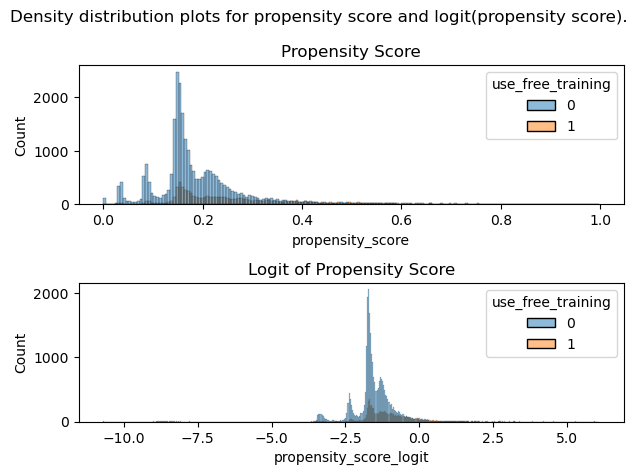

In [498]:
fig, ax = plt.subplots(2,1)
fig.suptitle('Density distribution plots for propensity score and logit(propensity score).')
ax[0].set_title('Propensity Score')
sns.histplot(data=df, x='propensity_score', hue=treatment,ax = ax[0]) 
ax[1].set_title('Logit of Propensity Score')
sns.histplot(data=df, x='propensity_score_logit', hue=treatment,ax = ax[1]) 
plt.tight_layout()
plt.show()

Looking at the logit density distribution, we have fare more treated than untreated users. However, the populations overlap in the plot. We can perform matching.

In [499]:
#reset user_ids values to be able to perform Knn
df = df.reset_index()

In [500]:
#our threshhold value, we choose to use 25% of standard deviation of propensity_score
caliper = np.std(df.propensity_score_logit) * 0.25
print('Caliper value is: {}'.format(caliper))

n_neighbors = 10
# setup knn
knn = NearestNeighbors(n_neighbors=n_neighbors,radius=caliper)
knn.fit(df[['propensity_score_logit']].to_numpy())

Caliper value is: 0.21111630279723545


NearestNeighbors(n_neighbors=10, radius=0.21111630279723545)

In [501]:
# we obtain at most 10 nearest matches for each user, regardless they are treated or not
distances , neighbor_indexes = knn.kneighbors(df[['propensity_score_logit']].to_numpy(), n_neighbors=10)
print('For item at index 0, the 4 closest distances are (first item is self):')
for ds,idx in zip(distances[0,0:4],neighbor_indexes[0,0:4]):
    print('Element distance: {}, element index : {}'.format(ds,idx))

For item at index 0, the 4 closest distances are (first item is self):
Element distance: 0.0, element index : 0
Element distance: 0.0012006596960048022, element index : 7627
Element distance: 0.0037907210233893984, element index : 31053
Element distance: 0.006259631667612897, element index : 11624


In [502]:
#previously matched elements
matched_control = set()  
# iterate over the dataframe
for current_index, row in df.iterrows():
    #match only if the user is treated, since lowest number of observations
    if (row[treatment] == 1):   
        #check nearest neighbors except self
        for idx in neighbor_indexes[current_index, 1:]: 
            # if the nearest neighbor is not treated and availabe
            if ((df.loc[idx][treatment] == 0) and (idx not in matched_control)):
                df.loc[current_index, 'matched'] = idx
                matched_control.add(idx)  
                break

In [503]:
print('total observations in control:', len(df[df[treatment]==0]))
print('total observations in treatment:', len(df[df[treatment]==1]))
print('total matched observations:', len(matched_control))

total observations in control: 26716
total observations in treatment: 7160
total matched observations: 6535


In [504]:
#only treatement group has matches
treatement_group = df.dropna(subset=['matched'])  # drop not matched
control_group = df.loc[treatement_group.matched.astype(int), :]  # select matched control observations
#combine the matched groups
matched_data = pd.concat([treatement_group, control_group])
matched_data[treatment].value_counts()

1    6535
0    6535
Name: use_free_training, dtype: int64

In [505]:
#some checks
print(treatement_group.user_id.is_unique)
print(control_group.user_id.is_unique)
print(set(treatement_group.user_id).intersection(set(control_group.user_id)))

True
True
set()


**Analyzing the Free training effect on scores**

In [506]:
def quantiles(df,feature):
    return df.groupby(treatment)[feature].apply(np.quantile,q=[0.25,0.5,0.75])

def mean_std(df,feature):
    return df.groupby(treatment)[feature].agg([np.mean,np.std])

**Absolute percentage score**

In [507]:
print(quantiles(matched_data,'absolute_percentage_correct'))
mean_std(matched_data,'absolute_percentage_correct')

use_free_training
0    [68.18181818181819, 77.08333333333333, 83.7837...
1                    [70.0, 78.125, 84.80702407545297]
Name: absolute_percentage_correct, dtype: object


,mean,std
use_free_training,,
0,74.59995,13.04115
1,76.44859,11.86745


p-value: 0.0000
We can reject null hypothesis


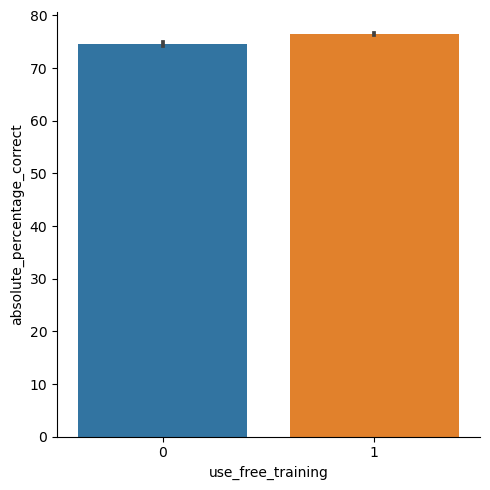

In [508]:
a=matched_data[['absolute_percentage_correct',treatment]]
sns.catplot(data=a, kind="bar", x=treatment, y='absolute_percentage_correct')
#conduct a t-test on means of different groups
_, p = stats.ttest_ind(a[a[treatment]==1].absolute_percentage_correct, a[a[treatment]==0].absolute_percentage_correct)
print("p-value: {:.4f}".format(p))
if(p<0.05):
    print("We can reject null hypothesis")

**Skills scores**

In [509]:
def report_skill_scores(skill) :
    a=matched_data[[skill,'max_level_solved']].apply(lambda x : x[skill][x.max_level_solved[skill]],axis=1).to_frame(name=skill)
    a[treatment]=matched_data[treatment]
    return a

def analyze_skill_score(skill) :
    skill_scores = report_skill_scores(skill)
    print('For skill {} : '.format(skill))
    print(quantiles(skill_scores,skill))
    print(mean_std(skill_scores,skill))
    #barplot the means
    sns.catplot(data=skill_scores, kind="bar", x=treatment, y=skill)
    _, p = stats.ttest_ind(a[a[treatment]==1].absolute_percentage_correct, a[a[treatment]==0].absolute_percentage_correct)
    print("p-value: {:.4f}".format(p))
    if(p<0.05):
        print("We can reject null hypothesis")

Addition

For skill Addition : 
use_free_training
0    [0.0, 50.0, 100.0]
1     [0.0, 0.0, 100.0]
Name: Addition, dtype: object
                      mean      std
use_free_training                  
0                 46.94726 46.68870
1                 43.44129 46.59149
p-value: 0.0000
We can reject null hypothesis


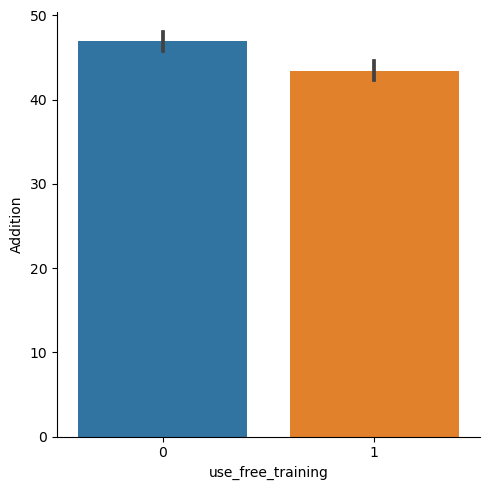

In [510]:
analyze_skill_score('Addition')

Substraction

For skill Subtraction : 
use_free_training
0    [0.0, 50.0, 100.0]
1    [0.0, 20.0, 100.0]
Name: Subtraction, dtype: object
                      mean      std
use_free_training                  
0                 47.18331 45.06670
1                 42.55284 45.28525
p-value: 0.0000
We can reject null hypothesis


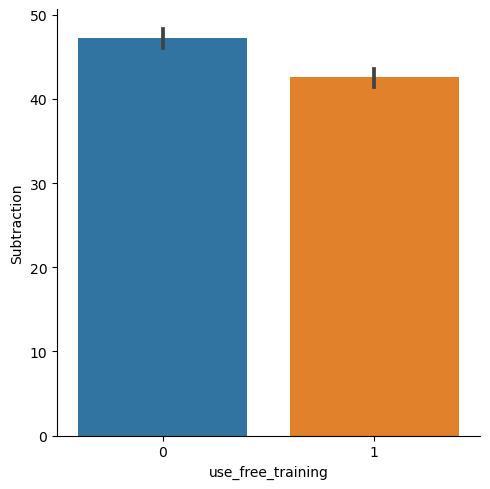

In [511]:
analyze_skill_score('Subtraction')

Division

For skill Division : 
use_free_training
0    [0.0, 0.0, 0.0]
1    [0.0, 0.0, 0.0]
Name: Division, dtype: object
                      mean      std
use_free_training                  
0                 19.18362 36.23942
1                 14.67380 32.63446
p-value: 0.0000
We can reject null hypothesis


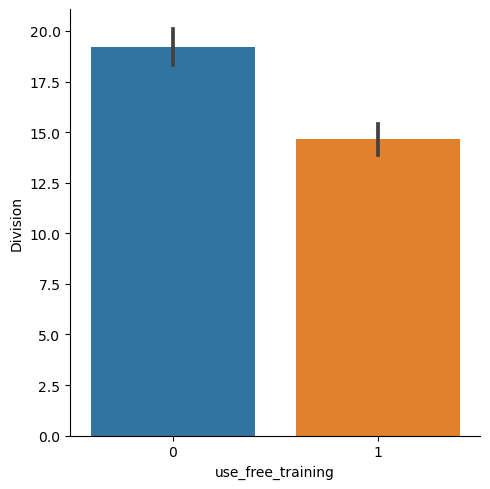

In [512]:
analyze_skill_score('Division')


Multiplication

For skill Multiplication : 
use_free_training
0    [0.0, 100.0, 100.0]
1    [0.0, 100.0, 100.0]
Name: Multiplication, dtype: object
                      mean      std
use_free_training                  
0                 67.76350 45.01142
1                 58.83681 47.77945
p-value: 0.0000
We can reject null hypothesis


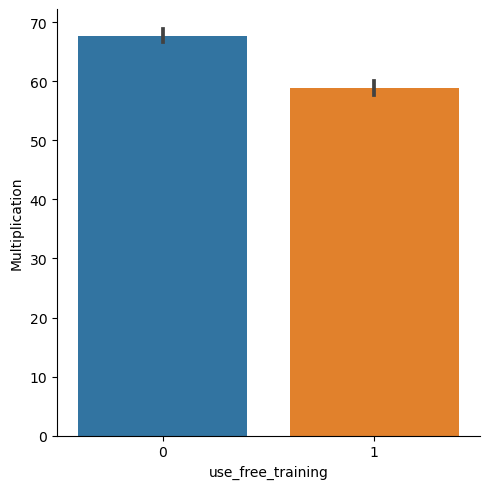

In [513]:
analyze_skill_score('Multiplication')

Number_line

For skill Number_line : 
use_free_training
0    [63.63636363636363, 77.77777777777777, 87.5]
1    [63.98198198198198, 77.77777777777777, 87.5]
Name: Number_line, dtype: object
                      mean      std
use_free_training                  
0                 73.98490 18.38359
1                 74.36117 17.99199
p-value: 0.0000
We can reject null hypothesis


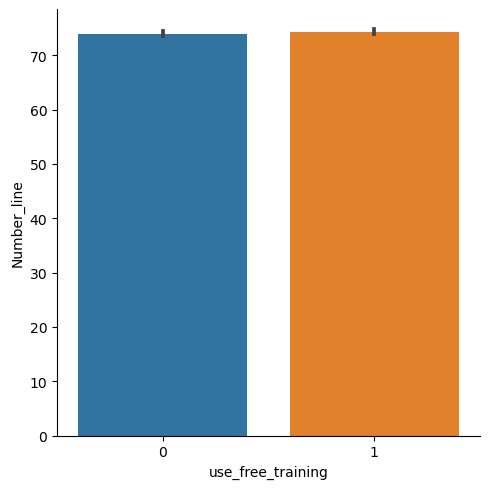

In [514]:
analyze_skill_score('Number_line')

Our results support that free_training users seem to perform better. The fact that guided users perform better in some skills but still get less correct answers overall can be explained by 'Number_line' category being the most dense in our data


## Observational study : Model Evaluation

Evaluate matched data on propensity score logit

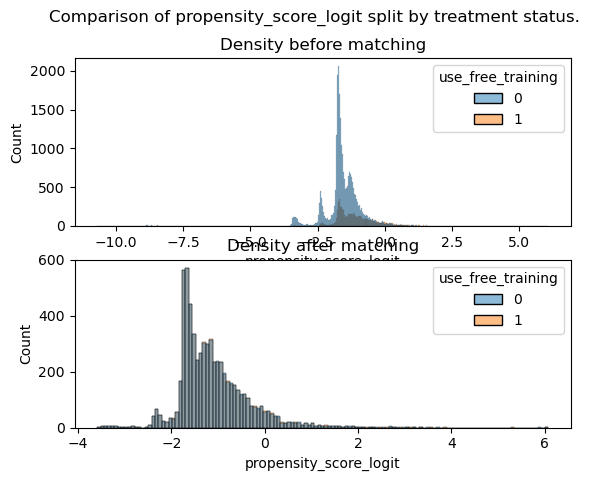

In [515]:
f='propensity_score_logit'
fig, ax = plt.subplots(2,1)
fig.suptitle('Comparison of {} split by treatment status.'.format(f))
sns.histplot(data = df, x = f, hue = treatment, ax = ax[0]).set(title='Density before matching')
sns.histplot(data = matched_data, x = f, hue = treatment,  ax = ax[1]).set(title='Density after matching')
plt.show()

The densities after the matching look comparable

Now we will try to grasp the effect of the covariates on the population using the Cohen's D function.   
Cohen's d is a measure of the standardized difference between two means, and it's commonly used to estimate the effect size observational studies.

In [516]:
from statistics import mean, stdev

def cohenD (x, y):
    return (mean(x) - mean(y)) / (np.sqrt((stdev(x) ** 2 + stdev(y) ** 2) / 2))

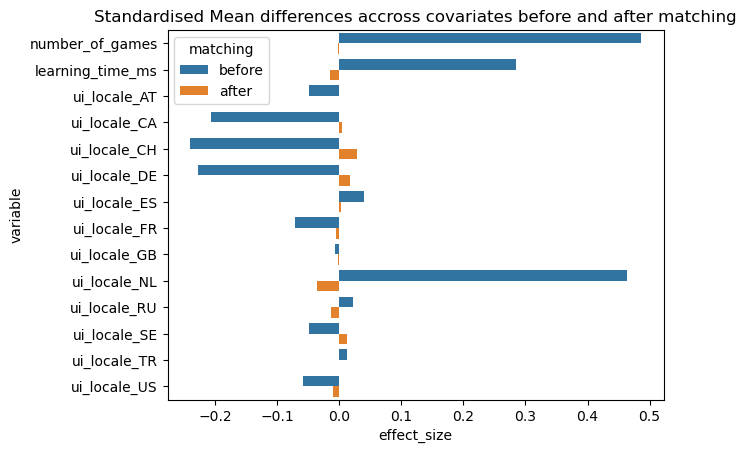

In [517]:
data = []
matched_data = matched_data[['ui_locale', 'number_of_games', 'learning_time_ms']+[treatment]]
matched_data=pd.get_dummies(matched_data, columns = ['ui_locale'], drop_first=False)
df=pd.get_dummies(df, columns = ['ui_locale'], drop_first=False)

cols = matched_data.columns

for cl in cols.drop(treatment):
    data.append([cl,'before', cohenD(df[df[treatment]==1][cl],df[df[treatment]==0][cl])])
    data.append([cl,'after', cohenD(matched_data[matched_data[treatment]==1][cl],matched_data[matched_data[treatment]==0][cl])])

res = pd.DataFrame(data, columns=['variable','matching','effect_size'])
sn_plot = sns.barplot(data = res, y = 'variable', x = 'effect_size', hue = 'matching', orient='h')
sn_plot.set(title='Standardised Mean differences accross covariates before and after matching')
sn_plot.figure.savefig("standardised_mean_differences.png")

We can see that the effect size is smal for all covariates, which means that the covariates do not have a big effect on the population. Hence the matching is good.